# 1. cfDNA simulator walkthrough

Demonstrates the chromatin-aware cfDNA simulator from Sec. 10 / App. E.

We sample (i) a per-locus ground-truth methylation track, (ii) nucleosome positions, (iii) fragment lengths from the three-mode mixture, and (iv) per-locus fragment bags for a small (S, L) panel.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt
import havi_methyl as hm

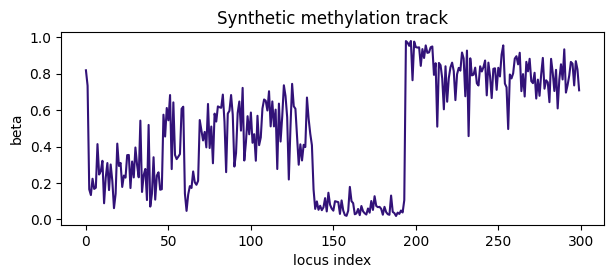

In [2]:
rng = np.random.default_rng(20260429)
track = hm.sample_methylation_track(L=300, rng=rng)
plt.figure(figsize=(7, 2.5))
plt.plot(track, color='#321278')
plt.ylabel('beta'); plt.xlabel('locus index'); plt.title('Synthetic methylation track');

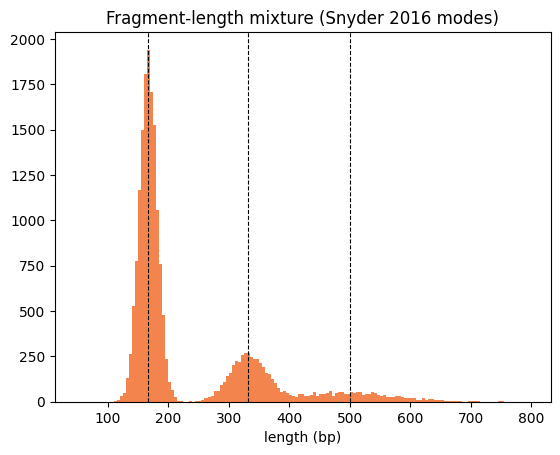

In [3]:
lengths = hm.sample_fragment_lengths(20000, rng=rng)
plt.hist(lengths, bins=np.arange(50, 800, 5), color='#F26522', alpha=0.8)
plt.axvline(167, color='k', ls='--', lw=0.8); plt.axvline(332, color='k', ls='--', lw=0.8); plt.axvline(500, color='k', ls='--', lw=0.8);
plt.title('Fragment-length mixture (Snyder 2016 modes)'); plt.xlabel('length (bp)');

In [4]:
sim = hm.simulate_dataset(S=4, L=120, coverage=5.0, rng=rng)
print('beta_pop range:', sim.beta_pop.min().round(3), sim.beta_pop.max().round(3))
print('mean fragments per locus:', sim.n.mean().round(2))
print('per-sample beta shape:', sim.beta_sample.shape)

beta_pop range: 0.031 0.963
mean fragments per locus: 5.0
per-sample beta shape: (4, 120)
